# Rome Alésia

## Importations

In [2]:
# LES ALGORITHMES
from QLearning import *
from DQN import *
from PPO import *
import time
import random
from stable_baselines3.common.env_checker import check_env

from ray.rllib.algorithms.dqn import DQNConfig
from ray.rllib.connectors.env_to_module import FlattenObservations
from pathlib import Path
from ray.rllib.core.rl_module import RLModule


# POUR AFFICHAGE
import matplotlib.pyplot as plt
import seaborn as sns
from helperPlot import *

# POUR ENVIRONNEMENT
import gymnasium
from gymnasium import spaces
from gymnasium.envs.toy_text.frozen_lake import generate_random_map

## Environnement

In [3]:
class RomeAlesiaEnv(gymnasium.Env) :

    def __init__(self, options = None) :
        super(RomeAlesiaEnv, self).__init__()
        nbUnits = options['nbUnits']
        nbSteps = options['nbSteps']

        
        self.nbUnits = nbUnits
        self.romeUnits = nbUnits
        self.alesiaUnits = nbUnits
        
        self.nbSteps = nbSteps
        self.romeLocation = 0
        self.alesiaLocation = 2 * nbSteps + 2
        self.battleFront = nbSteps + 1

        self.action_space = spaces.Discrete(nbUnits+1)
        self.observation_space = spaces.MultiDiscrete([2 * nbSteps + 3, nbUnits+1, nbUnits+1])


    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)

        self.romeUnits = self.nbUnits
        self.alesiaUnits = self.nbUnits
        self.battleFront = self.nbSteps +1 

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), {}


    def step(self, romeAction) :
        alesiaAction = random.randint(1, self.alesiaUnits+1)
        if romeAction <= 0 :
            romeAction = 1
        if alesiaAction <= 0 :
            alesiaAction = 1
        
        if romeAction > self.romeUnits :
            romeAction = self.romeUnits
        self.romeUnits -= romeAction

        if alesiaAction > self.alesiaUnits :
            alesiaAction = self.alesiaUnits
        self.alesiaUnits -= alesiaAction

        if romeAction > alesiaAction :
            self.battleFront += 1
        elif romeAction < alesiaAction :
            self.battleFront -= 1

        romeReward = 0
        done = False
        if self.battleFront == self.romeLocation :
            romeReward = -1
            done = True
        elif self.battleFront == self.alesiaLocation :
            romeReward = 1
            done = True

        if self.romeUnits == 0 and self.alesiaUnits == 0 :
            done = True

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), romeReward, done, False, {}


    def render(self) :
        toPrint = ""
        middlePoint = self.nbSteps + 1

        if self.battleFront != self.romeLocation :
            toPrint += "R"
        else :
            toPrint += "X"
        
        for i in range(1, self.nbSteps+1) :
            if i != self.battleFront :
                toPrint += "--|"
            else :
                toPrint += "--X"

        if self.battleFront != middlePoint :
            toPrint += "--M--"
        else :
            toPrint += "--X--"

        for i in range(1, self.nbSteps+1) :
            if i+middlePoint != self.battleFront :
                toPrint += "|--"
            else :
                toPrint += "X--"

        if self.battleFront != self.alesiaLocation :
            toPrint += "A"
        else :
            toPrint += "X"

        print(toPrint)
        print(f"Rome has {self.romeUnits} units remaining.")
        print(f"Alesia has {self.alesiaUnits} units remaining.")


In [3]:
env = RomeAlesiaEnv(
    {
        'nbUnits' : 20,
        'nbSteps' : 2
    }
)

check_env(env)

## QLearning

Essayons le QLearning par défaut

R--|--|--X--|--|--A
Rome has 20 units remaining.
Alesia has 20 units remaining.


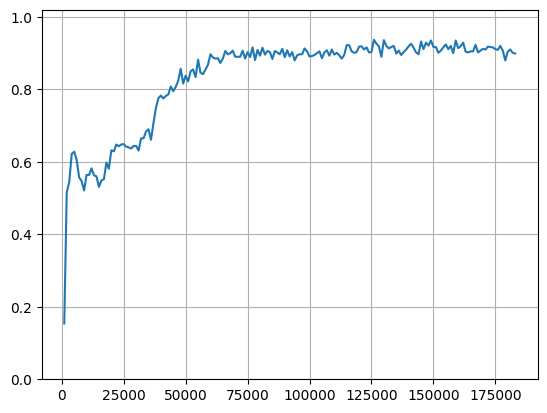

In [14]:
env = RomeAlesiaEnv(
    {
        'nbUnits' : 20,
        'nbSteps' : 2
    }
)
env.render()


model, reward, prodReward = train_q_learning(env, timesteps = 1000000, useProdForReward = True, maxTimestepsProd = 100,
                                            )


mean_n = 1000
somme = 0
actual_global = 0
actual_local = 0
toPlot = []
y = []
for i in range(len(prodReward)) :
    somme += prodReward[i]
    
    actual_global += 1
    actual_local += 1
    if actual_local == mean_n :
        y.append(actual_global)
        toPlot.append(somme / mean_n)
        mean = 0
        actual_local = 0
        somme = 0


plt.ylim(0, 1.02)
plt.plot(y, toPlot)
plt.grid()
plt.show()

Après paramétrage du QLearning

R--|--|--X--|--|--A
Rome has 20 units remaining.
Alesia has 20 units remaining.


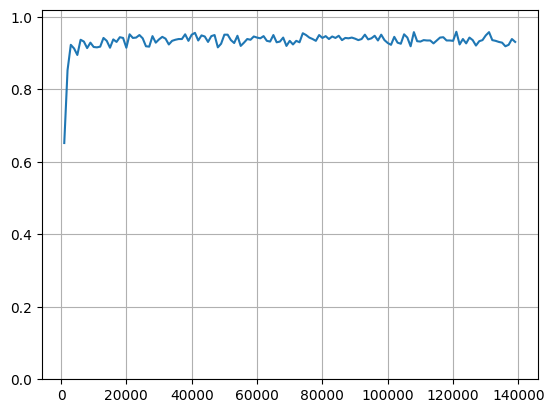

In [13]:
env = RomeAlesiaEnv(
    {
        'nbUnits' : 20,
        'nbSteps' : 2
    }
)
env.render()


model, reward, prodReward = train_q_learning(env, timesteps = 1000000, useProdForReward = True, maxTimestepsProd = 100,
                                             alpha = 0.1, eps_start = 0.05, eps_end = 0.05, eps_fraction = 0.8, gamma = 0.99
                                            )


mean_n = 1000
somme = 0
actual_global = 0
actual_local = 0
toPlot = []
y = []
for i in range(len(prodReward)) :
    somme += prodReward[i]
    
    actual_global += 1
    actual_local += 1
    if actual_local == mean_n :
        y.append(actual_global)
        toPlot.append(somme / mean_n)
        mean = 0
        actual_local = 0
        somme = 0


plt.ylim(0, 1.02)
plt.plot(y, toPlot)
plt.grid()
plt.show()

## DQN

R--|--|--X--|--|--A
Rome has 20 units remaining.
Alesia has 20 units remaining.


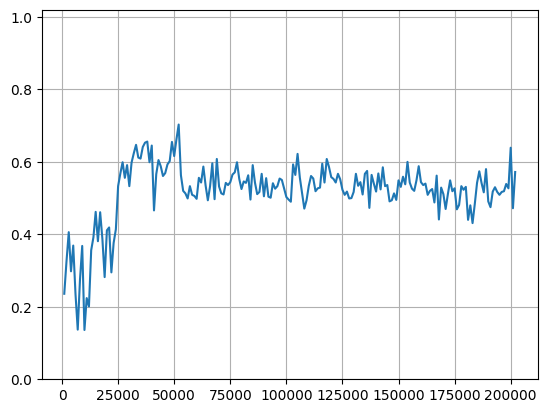

In [19]:
env = RomeAlesiaEnv(
    {
        'nbUnits' : 20,
        'nbSteps' : 2
    }
)
env.render()


model, reward, prodReward = train_dqn(env, timesteps = 1000000, useProdForReward = True, maxTimestepsProd = 100,
                                            )


mean_n = 1000
somme = 0
actual_global = 0
actual_local = 0
toPlot = []
y = []
for i in range(len(prodReward)) :
    somme += prodReward[i]
    
    actual_global += 1
    actual_local += 1
    if actual_local == mean_n :
        y.append(actual_global)
        toPlot.append(somme / mean_n)
        mean = 0
        actual_local = 0
        somme = 0


plt.ylim(0, 1.02)
plt.plot(y, toPlot)
plt.grid()
plt.show()

R--|--|--X--|--|--A
Rome has 20 units remaining.
Alesia has 20 units remaining.


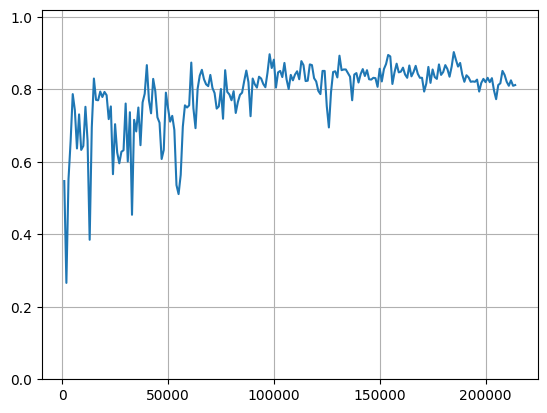

In [20]:
env = RomeAlesiaEnv(
    {
        'nbUnits' : 20,
        'nbSteps' : 2
    }
)
env.render()


model, reward, prodReward = train_dqn(env, timesteps = 1000000, useProdForReward = True, maxTimestepsProd = 100,
                                      learning_rate = 0.001, gamma = 0.99, buffer_size = 1000, batch_size = 32,
                                      update_freq = 50, exploration_initial_eps = 1, exploration_final_eps = 0.05,
                                      exploration_fraction = 0.8
                                     )


mean_n = 1000
somme = 0
actual_global = 0
actual_local = 0
toPlot = []
y = []
for i in range(len(prodReward)) :
    somme += prodReward[i]
    
    actual_global += 1
    actual_local += 1
    if actual_local == mean_n :
        y.append(actual_global)
        toPlot.append(somme / mean_n)
        mean = 0
        actual_local = 0
        somme = 0


plt.ylim(0, 1.02)
plt.plot(y, toPlot)
plt.grid()
plt.show()

R--|--|--X--|--|--A
Rome has 20 units remaining.
Alesia has 20 units remaining.


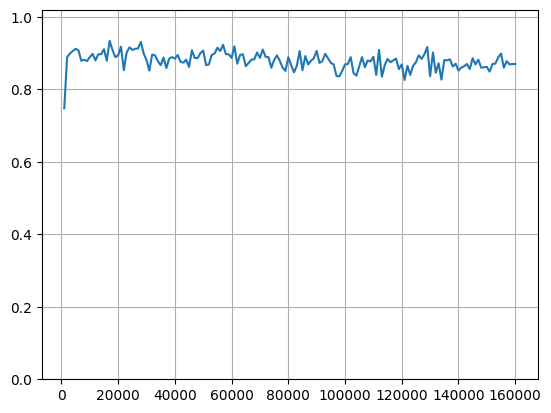

In [21]:
env = RomeAlesiaEnv(
    {
        'nbUnits' : 20,
        'nbSteps' : 2
    }
)
env.render()


model, reward, prodReward = train_dqn(env, timesteps = 1000000, useProdForReward = True, maxTimestepsProd = 100,
                                      learning_rate = 0.001, gamma = 0.99, buffer_size = 1000, batch_size = 32,
                                      update_freq = 50, exploration_initial_eps = 0.05, exploration_final_eps = 0.05,
                                      exploration_fraction = 0.8
                                     )


mean_n = 1000
somme = 0
actual_global = 0
actual_local = 0
toPlot = []
y = []
for i in range(len(prodReward)) :
    somme += prodReward[i]
    
    actual_global += 1
    actual_local += 1
    if actual_local == mean_n :
        y.append(actual_global)
        toPlot.append(somme / mean_n)
        mean = 0
        actual_local = 0
        somme = 0


plt.ylim(0, 1.02)
plt.plot(y, toPlot)
plt.grid()
plt.show()